## Script for producing figures based on monthly means:
- $\textbf{Figure 4}$: (a-b) $\tilde{A}/\overline{A}$ and $\tilde{F_b}/\overline{F_b}$ vs. SIE scatter plots, (c) $\tilde{F_b}/\overline{F_b}$ vs $\tilde{A}/\overline{A}$ scatter plot in the sea ice formation region, (d) monthly $\tilde{F_b}/\overline{F_b}$ vs $\tilde{A}/\overline{A}$ slopes, (e-h) monthly WMT rates.
  - IMPORTANT: Figure 4 requires the slopes_rs_wholeSIZ.npz, slopes_rs_formation.npz, slopes_rs_melt.npz files. If these do not exist, run ECCO_WMT_paper_correlationcalc.ipynb for each region's density range (whole SIZ, formation, melt).
- $\textbf{Figure S4}$: (a) $\tilde{F_b}/\overline{F_b}$ vs $\tilde{A}/\overline{A}$ scatter plot in the sea ice melt region, (b-c) June, July, August and December, January, February mean surface density distributions.
  - IMPORTANT: Figure S4a requires the slopes_rs_melt.npz file. If this do not exist, run ECCO_WMT_paper_correlationcalc.ipynb for the melt region's density range.

In [28]:
import gsw
import numpy as np
import netCDF4 as netcdf
from scipy import stats

import ecco_v4_py as ecco
import os
import glob
import pickle

from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import MultipleLocator
import matplotlib.path as mpath

import cmocean.cm as cmo
import cmocean

import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
import cartopy.feature as cfeature

In [2]:
# all helper functions are stored in v4r5_wmt_functions.py
import v4r5_wmt_func

** Same as first few steps in ECCO_WMT_paper_annual.ipynb -- see that notebook for more detailed descriptions **

In [3]:
label_fontsize = 13
tick_labelsize = 12

## Set-up for WMT calculation with ECCO V4r5

In [4]:
p = 2000 # sigma_2
rho0 = 1032 # reference density

rhomax = 1024
rhomin = 1039
nlevs = 300 # 0.05 kg m^-3 density bins
rholevs = np.linspace(rhomax, rhomin, nlevs)

In [5]:
grid_size = 1 # 1 degree grid
grid_size_str = str(grid_size).replace('.','')

In [6]:
v4r5_fp = '/export/data1/szhang6/ECCO2/LLC90/v4r5_monthly/'

In [7]:
pattern = "oceQnet.*.data" 
full_path_pattern = os.path.join(v4r5_fp, pattern)

# List files matching the pattern
matching_files = glob.glob(full_path_pattern)
hour_intervals = [file_path[-15:-5] for file_path in matching_files]
print(f'First hour interval: {hour_intervals[0]} ({v4r5_wmt_func.iteration_to_date(hour_intervals[0])})')
print(f'Last hour interval: {hour_intervals[-1]} ({v4r5_wmt_func.iteration_to_date(hour_intervals[-1])})')
print('Number of iterations saved: ', len(hour_intervals))

First hour interval: 0000000732 (1992-01-31 00:00:00)
Last hour interval: 0000288540 (2024-11-30 00:00:00)
Number of iterations saved:  395


## ECCO variables

In [8]:
var_pop = ['sst','sss','sfc_hflux_coupler','pme_river','melt']
ecco_vars = ['THETA', 'SALT', 'oceQnet', 'oceFWflx', 'SIatmFW']

file_vars = {'sst': 'THETA',
            'sss': 'SALT',
            'sfc_hflux_coupler': 'oceQnet',
            'pme_river': 'oceFWflx',
            'melt': ['oceFWflx', 'SIatmFW']}

# ASSUMES OUTPUTS ARE MONTHLY MEANS
monthly_mean = {}
for ecco_varname in ecco_vars:
    variable_monthly_means = {}
    
    for hr in hour_intervals:
        date = v4r5_wmt_func.iteration_to_date(hr)
        yr_month = f'{date.year}_{date.month}'
        daily_vals = v4r5_wmt_func.load_reproject_values(ecco_varname, hr)
        variable_monthly_means[yr_month] = daily_vals

    monthly_mean[ecco_varname] = variable_monthly_means
monthly_mean.keys()

dict_keys(['THETA', 'SALT', 'oceQnet', 'oceFWflx', 'SIatmFW'])

In [9]:
R = {}
for og_var_name, ecco_varname in file_vars.items():
    if og_var_name == 'melt':
        incl_si, no_si = ecco_varname[0], ecco_varname[1]
        diff_arrays = [
            a - b
            for a, b in zip(
                monthly_mean[incl_si].values(),
                monthly_mean[no_si].values()
            )]
        R[og_var_name] = diff_arrays
    else:
        R[og_var_name] = list(monthly_mean[ecco_varname].values())
R.keys()

dict_keys(['sst', 'sss', 'sfc_hflux_coupler', 'pme_river', 'melt'])

(180, 360) (180, 360) (180, 360)

Plot of native grid area:


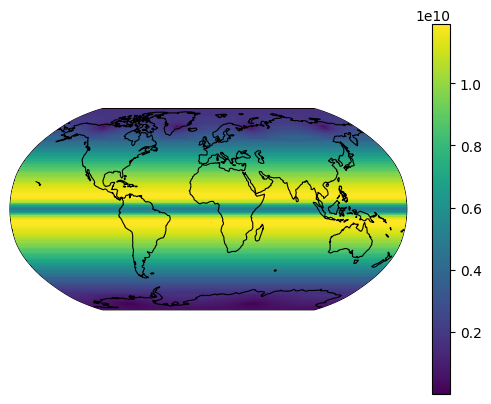

In [10]:
grid_fp = '/home/dmenemen/eady-data1/grid/ECCO_V4r5/'
ecco_XC = ecco.read_llc_to_tiles(grid_fp, 'XC.data', less_output=True)
ecco_YC = ecco.read_llc_to_tiles(grid_fp, 'YC.data', less_output=True)
ecco_RAC = ecco.read_llc_to_tiles(grid_fp, 'RAC.data', less_output=True)
projected_dummy_area = ecco.plot_proj_to_latlon_grid(ecco_XC, ecco_YC, ecco_RAC, show_colorbar=True, 
                                                     show_land=False, dx=grid_size, dy=grid_size);
X, Y = projected_dummy_area[4], projected_dummy_area[5]

with open(f'/home/szhang6/wmt/ecco_v4r5_{grid_size_str}deg_areas.pkl', 'rb') as f:
    area = pickle.load(f)

print(X.shape, Y.shape, area.shape)
print('\nPlot of native grid area:')

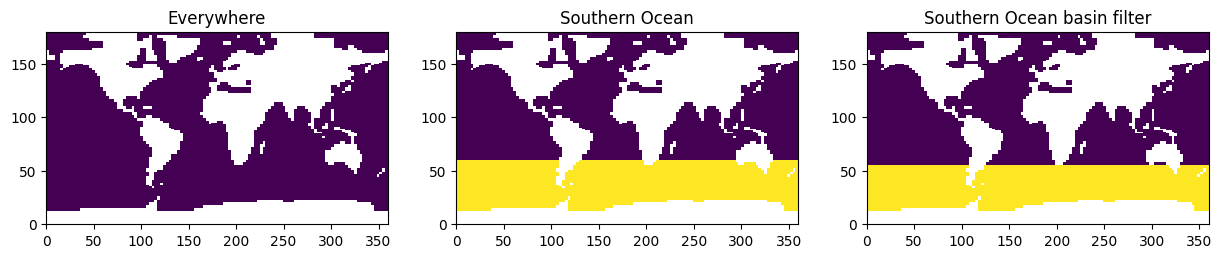

In [11]:
basin_file = netcdf.Dataset(f'basin_mask_regridded_ecco_v4r5_{grid_size_str}deg.nc')
basins = basin_file.variables['BASIN_MASK'][:]

SH = Y <= -30
SO = basins == 1
TOT = basins > 0

hems = ['TOT', 'SH', 'SO']
hem = [TOT, SH, SO]

# PLOT BASIN FILTERS:
fig, axs = plt.subplots(1,3, figsize=(15,2.5))
axs[0].pcolormesh(TOT)
axs[0].set_title('Everywhere');
axs[1].pcolormesh(TOT * SH)
axs[1].set_title('Southern Ocean');
axs[2].pcolormesh(SO)
axs[2].set_title('Southern Ocean basin filter');

## Calculate overall WMT rate

In [12]:
a,b = TOT.shape

Nt = len(R['sst']) #12
TRANS = dict()
TRANS_SI = dict()

# To store standard deviations
TRANS_sd = dict()
TRANS_SI_sd = dict()

trans = np.zeros((Nt,2,len(rholevs)-1))
trans_si = np.zeros((Nt,2,len(rholevs)-1))

rho = np.zeros((Nt,a,b))
rho_hems = dict()
alpha  = np.zeros((Nt,a,b))
beta = np.zeros((Nt,a,b))

t = np.zeros((Nt,a,b))
s = np.zeros((Nt,a,b))

Fdens_heat = np.zeros((Nt,a,b))
Fdens_salt = np.zeros((Nt,a,b))
Fdens_si = np.zeros((Nt,a,b))

In [13]:
cp = 3994 # specific heat of seawater at constant pressure [J/(kg K)]

for hem_i, hem_name in enumerate(hems): 
    mask = TOT.copy() * hem[hem_i]
    
    for f in range(Nt):     
        s = gsw.SA_from_SP(np.squeeze(R[var_pop[1]][f]) *  hem[hem_i],1,X,Y)  # sss
        t = gsw.CT_from_pt(s, np.squeeze(R[var_pop[0]][f]) *  hem[hem_i])  # sst
        hf = np.squeeze(R[var_pop[2]][f]) *  hem[hem_i] # heat flux
        fw = np.squeeze(R[var_pop[3]][f]) *  hem[hem_i]  # total freshwater flux
        si = np.squeeze(R[var_pop[4]][f]) *  hem[hem_i]  # sea ice freshwater flux
        hem_area = area.copy() *  hem[hem_i]

        # gsw.rho_alpha_beta calculates in-situ density, thermal expansion coefficient, and saline contraction coefficient 
        # of seawater from Absolute Salinity and Conservative Temperature
        rho[f,:,:], alpha[f,:,:], beta[f,:,:] = gsw.rho_alpha_beta(s,t,p) # p = 2000, defined in the beginning

        # these are the terms in equation 6
        cp = gsw.cp_t_exact(s, t, p)
        Fdens_heat[f,:,:] =  (- alpha[f,:,:] / cp * hf)*hem_area # first term
        Fdens_salt[f,:,:] =  (- beta[f,:,:] /1000 * s * fw * rho0)*hem_area # second term (rho0 = 1032, rhoFW = 1000)
        Fdens_si[f,:,:] =  (- beta[f,:,:] /1000 * s * si * rho0)*hem_area # second term, but only SI contribution (rho0 = 1032, rhoFW = 1000)

        # use equation 5 to calculate WMT
        trans[f,:,:] = v4r5_wmt_func.calculate_transformation_rate(rho[f,:,:], hem_area, mask, rholevs,Fdens_heat[f,:,:], Fdens_salt[f,:,:])
        trans_si[f,:,:] = v4r5_wmt_func.calculate_transformation_rate(rho[f,:,:], hem_area, mask, rholevs,Fdens_heat[f,:,:], Fdens_si[f,:,:])
       

    TRANS[hem_name]    = np.nanmean(trans, axis=0)
    TRANS_SI[hem_name] = np.nanmean(trans_si, axis=0)

    # --- reshape into (nyears, 12, ...) ---
    nyears = Nt // 12  # assumes Nt is divisible by 12
    
    trans_yr    = trans[:nyears*12].reshape(nyears, 12, *trans.shape[1:])
    trans_si_yr = trans_si[:nyears*12].reshape(nyears, 12, *trans_si.shape[1:])
    
    # --- annual means ---
    trans_ann    = np.nanmean(trans_yr, axis=1)
    trans_si_ann = np.nanmean(trans_si_yr, axis=1)
    
    # --- store means ---
    TRANS[hem_name]    = np.nanmean(trans, axis=0)
    TRANS_SI[hem_name] = np.nanmean(trans_si, axis=0)
    
    # --- interannual std (across years) ---
    TRANS_sd[hem_name]    = np.nanstd(trans_ann, axis=0)
    TRANS_SI_sd[hem_name] = np.nanstd(trans_si_ann, axis=0)

    fw_no_si_sd = np.nanstd(trans_ann[:, 1, :] - trans_si_ann[:, 1, :], axis=0)
    rho_hems[hem_name] = rho.copy()

## Figure 4

In [14]:
# Monthly colormap
month_colors = cmo.phase(np.linspace(0, 1, 12, endpoint=False))
month_cmap = mcolors.ListedColormap(month_colors)
norm = mcolors.BoundaryNorm(np.arange(0.5, 13.5, 1), month_cmap.N)
dates = [v4r5_wmt_func.iteration_to_date(hr) for hr in hour_intervals]
months = np.array([d.month for d in dates])
colors =[month_cmap(month - 1) for month in months]
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

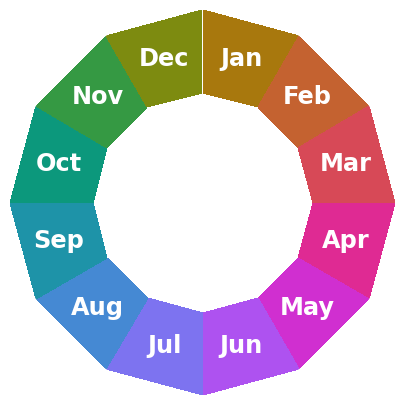

In [15]:
fig, ax = plt.subplots(figsize=(5, 5), subplot_kw={"projection": "polar"})

# Orient the polar axis: 0 at top, angles increase clockwise
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

# Angular bins (12 months)
theta = np.linspace(0, 2*np.pi, 13)
r = np.array([0.2, 0.35])   # inner and outer radius of the ring
Theta, R = np.meshgrid(theta, r)

# One value per month
C = np.arange(1, 13).reshape(1, -1)
ax.pcolormesh(
    Theta,
    R,
    C,
    cmap=month_cmap,
    norm=norm,
    shading="flat",
    antialiased=False,
    linewidth=0,
    edgecolor='none'
)

# Month labels
centers = (theta[:-1] + theta[1:]) / 2
ax.set_xticks(centers)
ax.set_xticklabels(
    month_labels,
    fontsize='xx-large',
    fontweight='bold',
    color='white'
)
ax.tick_params(axis='x', pad=-42)

# Hide radial ticks and frame
ax.set_yticks([])
ax.spines["polar"].set_visible(False)
ax.grid(False)
# fig.savefig("manuscript_figs/wmt_paper_month_colorwheel.png", dpi=300, transparent=True)

In [16]:
heat_wholets = trans[:, 0, :] / 1e6
fw_incl_si_wholets = trans[:, 1, :] / 1e6
si_wholets = trans_si[:, 1, :] / 1e6

all_vars_ts = {
    'Heat': heat_wholets,
    'Sea Ice': si_wholets,
    'Freshwater': fw_incl_si_wholets - si_wholets,
    'Total': heat_wholets + fw_incl_si_wholets,
}

var_colors = {'Total': 'k',
              'Heat': 'tab:red',
             'Freshwater':'tab:blue',
             'Sea Ice':'tab:grey'}

In [17]:
sigma2s = rholevs[1:] - 1000

## Fig. 4e-h

<>:35: SyntaxWarning: invalid escape sequence '\s'
<>:35: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2964998/2043323730.py:35: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel("$\sigma_2~[kg~m^{-3}]$", fontsize = label_fontsize + 4)


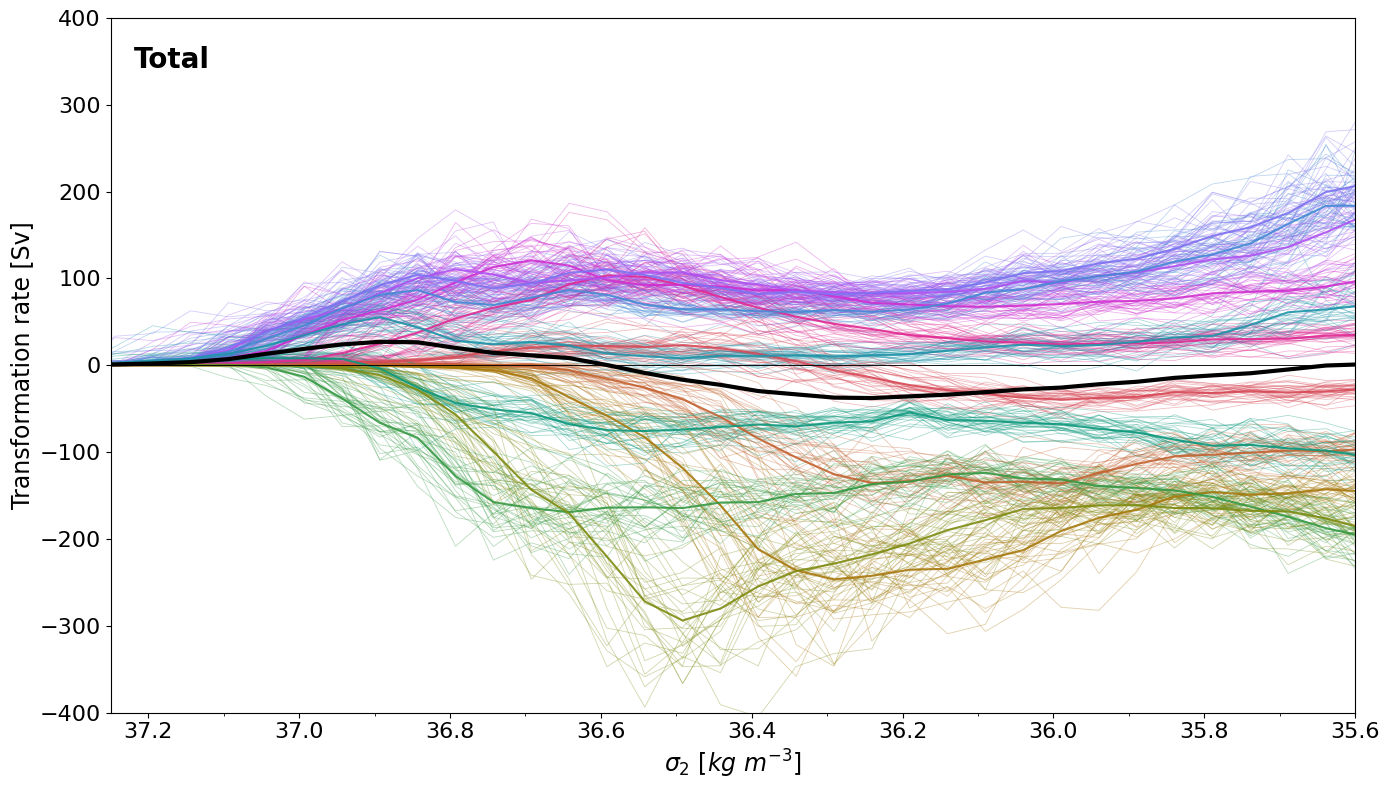

In [18]:
fig, ax = plt.subplots(1, figsize=(14, 8), sharex=True, sharey=False)

var = 'Total'
var_ts = all_vars_ts[var]

# Plot individual monthly curves (thin colored lines)
for j, monthly_field in enumerate(var_ts):
    ax.plot(sigma2s, monthly_field,
            linewidth=0.6, alpha=0.35,
            color=colors[j])

# Plot monthly means (thick colored lines)
for m in range(1, 13):
    month_mask = (months == m)
    if np.any(month_mask):
        monthly_mean = np.nanmean(var_ts[month_mask], axis=0)
        ax.plot(sigma2s, monthly_mean,
                linewidth=1.5, alpha=0.9,
                color = month_cmap(m - 1))

# Plot annual mean (thick black line)
var_mean = np.nanmean(var_ts, axis=0)
ax.plot(sigma2s, var_mean, linewidth=3, color='black', label='mean')

# Aesthetics
ax.axhline(0, color='black', linewidth=0.65)
ax.text(0.08, 0.92, var,
    transform=ax.transAxes,
    ha='right', va='bottom',
    fontsize=20, fontweight='bold',
    color=var_colors[var])

ax.tick_params(axis='both', labelsize=tick_labelsize + 4)
ax.set_xlim(37.25, 35.6)
ax.set_xlabel("$\sigma_2~[kg~m^{-3}]$", fontsize = label_fontsize + 4)
ax.xaxis.set_minor_locator(MultipleLocator(0.1))
ax.set_ylim(-400, 400)
ax.set_ylabel('Transformation rate [Sv]', fontsize=label_fontsize + 4)

fig.tight_layout()
plt.show()
# fig.savefig('manuscript_figs/wmt_paper_fig4_e.png', dpi=1200)

<>:38: SyntaxWarning: invalid escape sequence '\s'
<>:38: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2964998/3962329699.py:38: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel("$\sigma_2~[kg~m^{-3}]$", fontsize=label_fontsize + 5)


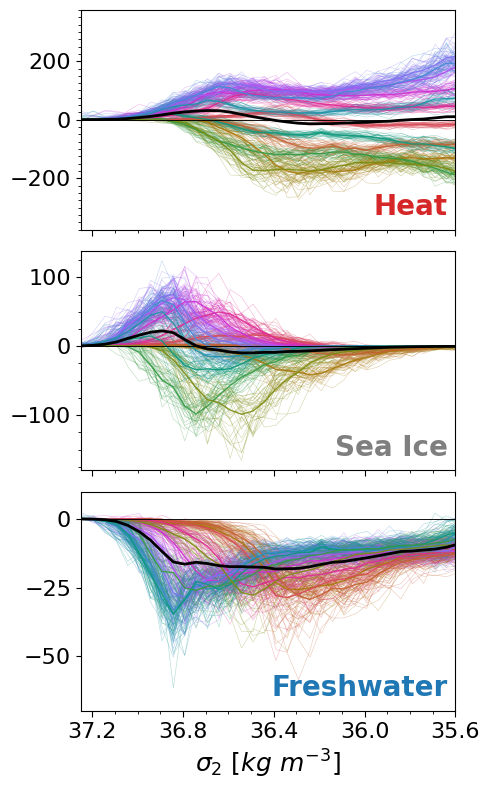

In [19]:
fig, axs = plt.subplots(3, 1, figsize=(5, 8), sharex=True, sharey=False)

# 1 variable per panel
for i, ax in enumerate(axs.flatten()):
    var = list(all_vars_ts.keys())[i]
    var_ts = all_vars_ts[var]

    # Plot individual monthly curves (thin colored lines)
    for j, monthly_field in enumerate(var_ts):
        ax.plot(sigma2s, monthly_field,
                linewidth=0.4, alpha=0.35,
                color=colors[j])

    # Plot monthly means (thick colored lines)
    for m in range(1, 13):
        month_mask = (months == m)
        if np.any(month_mask):
            monthly_mean = np.nanmean(var_ts[month_mask], axis=0)
            ax.plot(sigma2s, monthly_mean,
                    linewidth=1, alpha=0.9,
                    color = month_cmap(m - 1))

    # Plot annual mean (thick black line)
    var_mean = np.nanmean(var_ts, axis=0)
    ax.plot(sigma2s, var_mean, linewidth=2, color='black', label='mean')

    # Aesthetics
    ax.text(0.98, 0.04, var,
        transform=ax.transAxes,
        ha='right', va='bottom',
        fontsize=20, fontweight='bold',
        color=var_colors[var])
    ax.set_xlim(37.25, 35.6)
    ax.tick_params(axis='both', labelsize=tick_labelsize + 4)
    ax.tick_params(axis='x', length=4.5)
    
    if i == 2:
        ax.set_xlabel("$\sigma_2~[kg~m^{-3}]$", fontsize=label_fontsize + 5)
    if var == 'Heat':
        ax.set_ylim(-375, 375)
    if var == 'Freshwater':
        ax.set_ylim(-70, 10)
        ax.yaxis.set_major_locator(MultipleLocator(25))
    ax.yaxis.set_minor_locator(MultipleLocator(25))
    
    ax.axhline(0, color='black', linewidth=0.65)
    ax.xaxis.set_minor_locator(MultipleLocator(0.1))
    ax.xaxis.set_major_locator(MultipleLocator(0.4))

fig.tight_layout()
plt.show()
# fig.savefig('manuscript_figs/wmt_paper_fig4_fgh.png', dpi=1200)

## Figure S4b-c

/tmp/ipykernel_2964998/3156605703.py:11: RuntimeWarning: Mean of empty slice
  rho_jja = np.nanmean(rho_hems["TOT"][np.isin(months, [6, 7, 8])], axis=0)
/tmp/ipykernel_2964998/3156605703.py:12: RuntimeWarning: Mean of empty slice
  rho_djf = np.nanmean(rho_hems["TOT"][np.isin(months, [12, 1, 2])], axis=0)


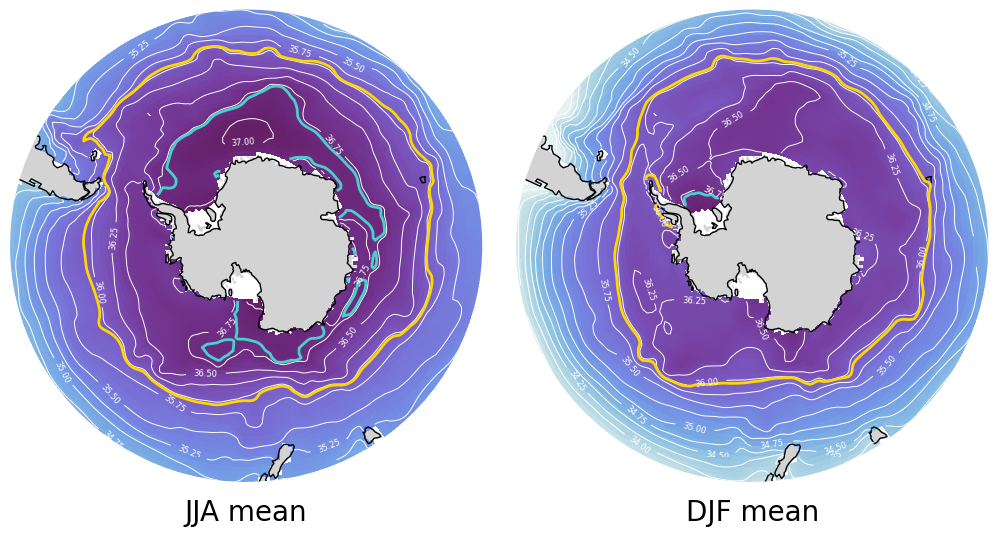

In [20]:
fig, axs = plt.subplots(
    1, 2, figsize=(10, 6),
    subplot_kw={"projection": ccrs.SouthPolarStereo()}
)

rho_lev_min, rho_lev_max = 33.5, 37.8
rho_levels = np.arange(rho_lev_min, rho_lev_max, 0.25)
highlight_levels = {35.95: "gold", 36.79: "mediumturquoise"}

# Seasonal means
rho_jja = np.nanmean(rho_hems["TOT"][np.isin(months, [6, 7, 8])], axis=0)
rho_djf = np.nanmean(rho_hems["TOT"][np.isin(months, [12, 1, 2])], axis=0)

# Cyclic longitude to eliminate seam
lon, lat = X[0, :], Y[:, 0]
lon_cyclic = add_cyclic_point(lon, coord=lon)[1]
Xc, Yc = np.meshgrid(lon_cyclic, lat)

land = cfeature.NaturalEarthFeature("physical", "land", "50m", edgecolor="face", facecolor="lightgray")

# Circular map boundary
theta = np.linspace(0, 2 * np.pi, 100)
center, radius = [0.5, 0.5], 0.56
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)

for ax, rho_mean, title in zip(axs, [rho_jja, rho_djf], ["JJA mean", "DJF mean"]):
    rho_cyclic, _ = add_cyclic_point(rho_mean, coord=lon)
    rho_so = np.where(Yc < 0, rho_cyclic, np.nan) - 1000

    ax.set_extent([-180, 180, -90, -45], crs=ccrs.PlateCarree())
    ax.set_boundary(circle, transform=ax.transAxes)
    ax.spines["geo"].set_visible(False)  # remove black border around panel

    ax.pcolormesh(Xc, Yc, rho_so, transform=ccrs.PlateCarree(),
                  cmap=cmocean.cm.dense, vmin=rho_lev_min, vmax=rho_lev_max, shading="auto")

    cs = ax.contour(Xc, Yc, rho_so, levels=rho_levels, colors="white",
                     linewidths=0.7, transform=ccrs.PlateCarree())
    ax.clabel(cs, fmt="%.2f", fontsize=6, colors="white", inline=True)

    for lev, color in highlight_levels.items():
        ax.contour(Xc, Yc, rho_so, levels=[lev], colors=color,
                   linewidths=2, transform=ccrs.PlateCarree())

    ax.add_feature(land, zorder=0)
    ax.coastlines(resolution="110m", color="black", linewidth=1)
    ax.set_title(title, y=-.17, fontsize=20)  # push title above the circle

fig.tight_layout()
fig.subplots_adjust(wspace=0.2)
# fig.savefig('manuscript_figs/wmt_paper_supfig_sigmamaps', dpi=1200)

## Figure 4a-d
#### Run ECCO_WMT_paper_correlationcalc.ipynb for all 3 sigma2 ranges (sea ice formation, melt, whole SIZ) before running this section!

In [21]:
# Load data 
wholesiz_fn = 'slopes_rs_wholeSIZ.npz'
formation_fn = 'slopes_rs_formation.npz'
melt_fn = 'slopes_rs_melt.npz'

wholesiz_data = np.load(wholesiz_fn, allow_pickle=True)
formation_data = np.load(formation_fn, allow_pickle=True)
melt_data = np.load(melt_fn, allow_pickle=True)

regions = {
    'Whole SIZ': wholesiz_data,
    'Formation': formation_data,
    'Melt':      melt_data,
}

In [22]:
region_colors = {
    'Whole SIZ': 'grey',
    'Formation': 'paleturquoise',
    'Melt':      'gold',
}

region_markers = {
    'Whole SIZ': 'o',
    'Formation': '^',
    'Melt':      's',
}

In [23]:
# Each relationship maps a short key -> (monthly_slopes, monthly_rs, monthly_pvals, overalls) variable names
relationships = {
    "A'/Abar vs F'/Fbar": dict(
        monthly_slopes='Aprime_Fprime_monthly_slopes',
        monthly_rs='Aprime_Fprime_monthly_rs',
        monthly_pvals='Aprime_Fprime_monthly_pvals',
        overalls='Aprime_Fprime_overalls',
        ylabel="slope (A'/F')",
    ),
    "A'/Abar vs SIE": dict(
        monthly_slopes='Aprime_SIE_monthly_slopes',
        monthly_rs='Aprime_SIE_monthly_rs',
        monthly_pvals='Aprime_SIE_monthly_pvals',
        overalls='Aprime_SIE_overalls',
        ylabel="slope (A' vs SIE)",
    ),
    "F'/Fbar vs SIE": dict(
        monthly_slopes='Fprime_SIE_monthly_slopes',
        monthly_rs='Fprime_SIE_monthly_rs',
        monthly_pvals='Fprime_SIE_monthly_pvals',
        overalls='Fprime_SIE_overalls',
        ylabel="slope (F' vs SIE)",
    ),
}

def get_monthly_dict(npz_data, varname):
    """Extract a per-region dictionary {month: value} from npz object array. """
    return npz_data[varname].item()

def r_to_markersize(r, smin=15, smax=170):
    """Map |r| in [0, 1] to a marker area in [smin, smax]."""
    return smin + (smax - smin) * np.abs(r)

<>:18: SyntaxWarning: invalid escape sequence '\o'
<>:20: SyntaxWarning: invalid escape sequence '\o'
<>:18: SyntaxWarning: invalid escape sequence '\o'
<>:20: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_2964998/3050244485.py:18: SyntaxWarning: invalid escape sequence '\o'
  ylabel=r"$\tilde{A}/\overline{A}$", title="$A'/\overline{A}$ vs SIE"),
/tmp/ipykernel_2964998/3050244485.py:20: SyntaxWarning: invalid escape sequence '\o'
  ylabel=r"$\tilde{F}_b/\overline{F_b}$", title="$F'/\overline{F}$ vs SIE"),


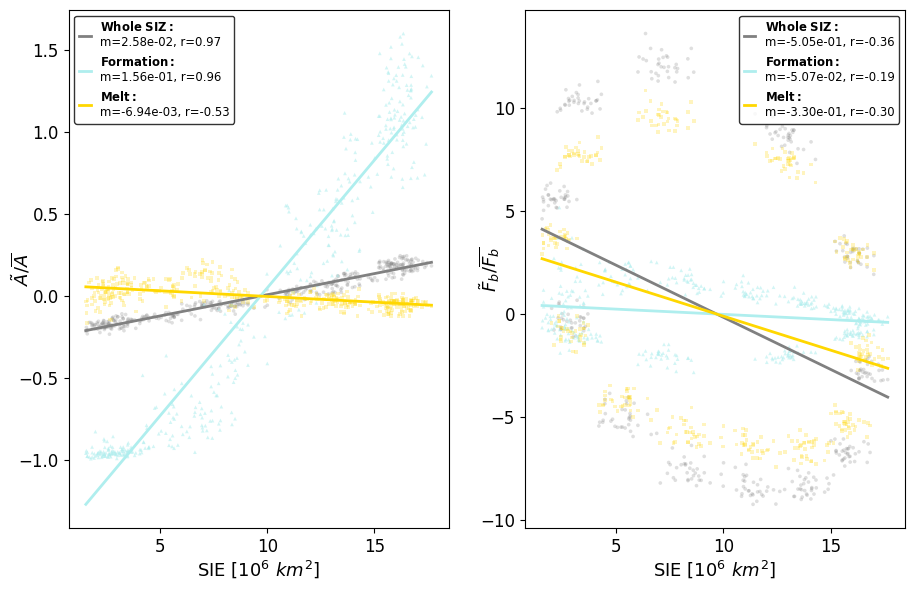

In [24]:
def fit_and_residuals(npz_data, xvar, yvar):
    """Fit + residuals for one region/relationship"""
    x = np.asarray(npz_data[xvar]).flatten()
    y = np.asarray(npz_data[yvar]).flatten()
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    slope, intercept, r, p, _ = stats.linregress(x, y)
    y_fit = slope * x + intercept
    resid = y - y_fit
    return dict(x=x, y=y, slope=slope, intercept=intercept, r=r, p=p, resid=resid)

# Plot results
fig, axs = plt.subplots(
    1, 2, figsize=(9.25, 6),
)
panel_specs = [
    dict(col=0, xvar='monthly_sie', yvar='monthly_Aprime_over_Abar',
         ylabel=r"$\tilde{A}/\overline{A}$", title="$A'/\overline{A}$ vs SIE"),
    dict(col=1, xvar='monthly_sie', yvar='monthly_Fprime_over_Fbar',
         ylabel=r"$\tilde{F}_b/\overline{F_b}$", title="$F'/\overline{F}$ vs SIE"),
]
for spec in panel_specs:
    col = spec['col']
    ax = axs[col]
    fits = {}
    
    for region_name in ['Whole SIZ', 'Formation', 'Melt']:
        npz_data = regions[region_name]
        color = region_colors[region_name]
        marker = region_markers[region_name]
        fit = fit_and_residuals(npz_data, spec['xvar'], spec['yvar'])
        fits[region_name] = fit
        x, y = fit['x'], fit['y']
        scatter_alpha = 0.25
        if region_name == 'Formation':
            scatter_alpha = 0.55
        ax.scatter(x, y, s=7, color=color, marker=marker, alpha=scatter_alpha, edgecolors='none')
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = fit['slope'] * x_line + fit['intercept']
        ax.plot(
            x_line, y_line, color=color, linewidth=2,
            label=f"$\\bf{{{region_name.replace(' ', '\\ ')}}}:$\nm={fit['slope']:.2e}, r={fit['r']:.2f}",
        )
    ax.tick_params(axis='both', labelsize=tick_labelsize)
    ax.set_ylabel(spec['ylabel'], labelpad=-10, fontsize=label_fontsize)
    ax.set_xlabel(r'SIE [$10^6~km^2$]', labelpad=2, fontsize=label_fontsize)
    ax.legend(fontsize='small', loc='best', handlelength=1, edgecolor='black')

ax.set_ylabel(spec['ylabel'], labelpad=-16, fontsize=label_fontsize)

fig.tight_layout()
fig.subplots_adjust(wspace=0.2)
plt.show()
# fig.savefig('manuscript_figs/monthly_panels_ab.png', dpi=1200)

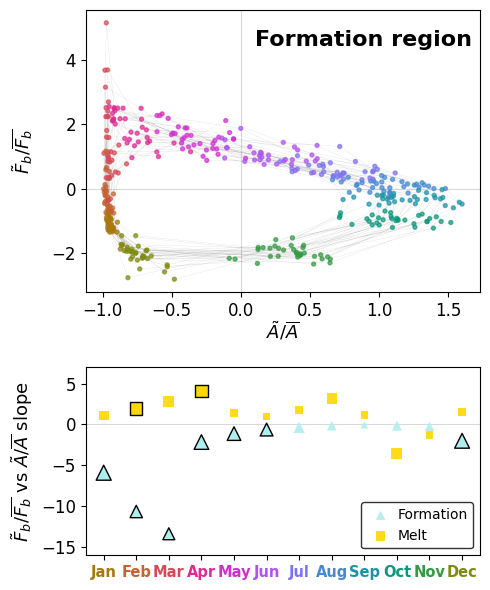

In [25]:
only_individual_regions = regions.copy()
only_individual_regions.pop('Whole SIZ')

pval_thresh = 0.05
info = relationships["A'/Abar vs F'/Fbar"]

fig, axes = plt.subplots(
    2, 1, figsize=(5, 6), gridspec_kw={'height_ratios': [1.5, 1]}
)
ax_top, ax_bot = axes

# ---------------- Top panel: F' vs A' scatter, formation region, colored by month ----------------
formation_data = only_individual_regions['Formation']
x_top = formation_data['monthly_Aprime_over_Abar']
y_top = formation_data['monthly_Fprime_over_Fbar']
months_top = formation_data['months']

ax_top.scatter(x_top, y_top, c=months_top, cmap=month_cmap, norm=norm, s=8, alpha=0.7,)
ax_top.axhline(0, color='k', linewidth=0.8, alpha=0.15, zorder=0)
ax_top.axvline(0, color='k', linewidth=0.8, alpha=0.15, zorder=0)
ax_top.set_xlabel(r"$\tilde{A}/\overline{A}$", fontsize=label_fontsize, labelpad=0)
ax_top.set_ylabel(r"$\tilde{F}_b/\overline{F_b}$", fontsize=label_fontsize)
ax_top.tick_params(axis='both', labelsize=tick_labelsize)

ax_top.text(0.98, 0.93, 'Formation region',
        transform=ax_top.transAxes,
        ha='right', va='top',
        fontsize=16, fontweight='bold',
        color='k',
        )

ax_top.plot(x_top, y_top, color='k',
          linewidth=0.15, alpha=0.2, zorder=0)

# ---------------- Bottom panel: monthly slopes ----------------
for region_name, npz_data in only_individual_regions.items():
    color = region_colors[region_name]
    marker = region_markers[region_name]
    monthly_slopes = get_monthly_dict(npz_data, info['monthly_slopes'])
    monthly_rs = get_monthly_dict(npz_data, info['monthly_rs'])
    monthly_pvals = get_monthly_dict(npz_data, info['monthly_pvals'])
    
    months_sorted = sorted(monthly_slopes.keys())
    slopes = np.array([monthly_slopes[m] for m in months_sorted])
    rs = np.array([monthly_rs[m] for m in months_sorted])
    pvals = np.array([monthly_pvals[m] for m in months_sorted])
    months_arr = np.array(months_sorted)
    sizes = r_to_markersize(rs)
    significance_mask = pvals < pval_thresh

    ax_bot.scatter(
        months_arr[~significance_mask], slopes[~significance_mask],
        s=sizes[~significance_mask], c=color, marker=marker,
        alpha=0.9, edgecolors='none',
        label=f'{region_name}',
    )
    ax_bot.scatter(
        months_arr[significance_mask], slopes[significance_mask],
        s=sizes[significance_mask], c=color, marker=marker,
        alpha=1, edgecolors='k', linewidths=1.0,
    )
ax_bot.axhline(0, color='k', linewidth=0.8, alpha=0.15, zorder=0)
ax_bot.set_ylim(-16, 7)
ax_bot.set_xticks(np.arange(1, 13))
ax_bot.set_xticklabels(month_labels, fontweight='bold', fontsize=10.5)
ax_bot.tick_params(axis='y', labelsize=tick_labelsize)
for tick, month in zip(ax_bot.get_xticklabels(), np.arange(1, 13)):
    tick.set_color(month_cmap(month - 1))
ax_bot.set_ylabel(r"$\tilde{F}_b/\overline{F_b}$ vs $\tilde{A}/\overline{A}$ slope", fontsize=label_fontsize)

handles, labels = ax_bot.get_legend_handles_labels()
ax_bot.legend(handles, labels, fontsize='medium', ncol=1, loc='lower right', edgecolor='black', handletextpad = 0.2)

fig.tight_layout()
fig.align_ylabels(axes)
fig.subplots_adjust(hspace=0.32)
plt.show()
# fig.savefig('manuscript_figs/monthly_panels_cd.png', dpi=1200)

## Fig. S4a

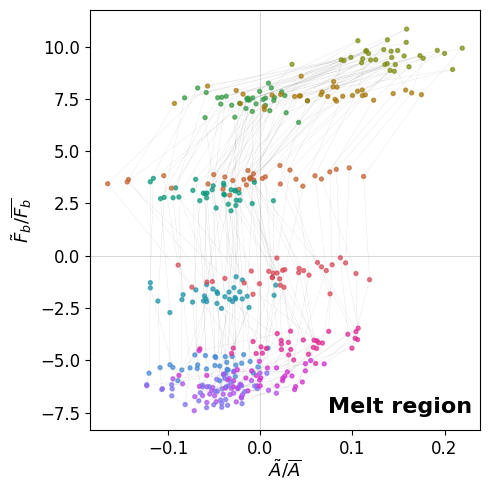

In [27]:
# SUPPLEMENTAL FIGURE:
fig, ax_top = plt.subplots(1, figsize=(5, 5))

melt_data = only_individual_regions['Melt']
x_top = melt_data['monthly_Aprime_over_Abar']
y_top = melt_data['monthly_Fprime_over_Fbar']
months_top = melt_data['months']

ax_top.scatter(x_top, y_top, c=months_top, cmap=month_cmap, norm=norm, s=8, alpha=0.7,)
ax_top.axhline(0, color='k', linewidth=0.8, alpha=0.15, zorder=0)
ax_top.axvline(0, color='k', linewidth=0.8, alpha=0.15, zorder=0)
ax_top.set_xlabel(r"$\tilde{A}/\overline{A}$", fontsize=label_fontsize, labelpad=0)
ax_top.set_ylabel(r"$\tilde{F}_b/\overline{F_b}$", fontsize=label_fontsize)
ax_top.tick_params(axis='both', labelsize=tick_labelsize)

ax_top.text(0.98, 0.03, 'Melt region',
        transform=ax_top.transAxes,
        ha='right', va='bottom',
        fontsize=16, fontweight='bold',
        color='k',
        )

ax_top.plot(x_top, y_top, color='k',
          linewidth=0.15, alpha=0.2, zorder=0)

fig.tight_layout()
# fig.savefig('manuscript_figs/wmt_paper_supfig_FprimeAprime_melt.png', dpi=1200)